In [1]:
from google.colab import userdata
from pathlib import Path
import subprocess
import os

token = userdata.get("GITHUB_TOKEN")

# Identify your commits
!git config --global user.name "Hok Seng"
!git config --global user.email "senghok789@gmail.com"

# Authenticate without embedding token in remote URL
askpass = Path("/tmp/git-askpass.sh")
askpass.write_text(
    '#!/bin/sh\n'
    'case "$1" in\n'
    '  *Username*) echo "$GITHUB_USERNAME" ;;\n'
    '  *Password*) echo "$GITHUB_TOKEN" ;;\n'
    'esac\n'
)
askpass.chmod(0o700)

os.environ["GITHUB_USERNAME"] = "Hok Seng"
os.environ["GITHUB_TOKEN"] = token
os.environ["GIT_ASKPASS"] = str(askpass)
os.environ["GIT_TERMINAL_PROMPT"] = "0"

In [3]:
%cd /content/astro_dino_v2

/content/astro_dino_v2


In [4]:
!git remote -v

origin	https://github.com/senghok510/astro_dino_v2.git (fetch)
origin	https://github.com/senghok510/astro_dino_v2.git (push)


In [5]:
import copy
import gc
import json
import os
import random
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from datasets import load_dataset
from huggingface_hub import HfApi
from sklearn.metrics import (accuracy_score,classification_report,ConfusionMatrixDisplay,confusion_matrix,f1_score)
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import transforms
from tqdm.auto import tqdm

SEED = 42
MODEL_NAME = "dinov2_vits14"
EMBEDDING_DIM = 384
IMAGE_SIZE = 224

FEATURE_BATCH_SIZE = 32
TRAIN_BATCH_SIZE = 64
EPOCHS = 30
LEARNING_RATE = 4e-3

DATASET_ID = "MultimodalUniverse/gz10"
OUTPUT_DIR = Path("/content/astrodino_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("PyTorch:", torch.__version__)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError(
        "Enable a GPU under Runtime → Change runtime type, then rerun."
    )

CLASS_NAMES = [
    "Disturbed",
    "Merging",
    "Round smooth",
    "Intermediate smooth",
    "Cigar-shaped smooth",
    "Barred spiral",
    "Unbarred tight spiral",
    "Unbarred loose spiral",
    "Edge-on without bulge",
    "Edge-on with bulge",
]

Device: cuda
PyTorch: 2.11.0+cu130
GPU: NVIDIA A100-SXM4-40GB


In [6]:
DATASET_REVISION = HfApi().dataset_info(DATASET_ID).sha

print("Dataset revision:", DATASET_REVISION)

galaxies = load_dataset(DATASET_ID,revision=DATASET_REVISION,split="train",)

print(galaxies)
print("Columns:", galaxies.column_names)

assert "rgb_image" in galaxies.column_names
assert "gz10_label" in galaxies.column_names

labels = np.asarray(galaxies["gz10_label"], dtype=np.int64)

assert np.array_equal(np.unique(labels), np.arange(10))

print("\nNumber of images:", len(galaxies))

counts = np.bincount(labels, minlength=10)

for class_id, count in enumerate(counts):
    print(f"{class_id}: {CLASS_NAMES[class_id]:25s} {count:5d}")

Dataset revision: eed0f087b8e3eb3316d303a8244199c2667d46fb


README.md:   0%|          | 0.00/5.27k [00:00<?, ?B/s]

gz10_rgb_images/train-00000-of-00002.par(…): reconstructing file:   0%|          |  0.00B / 1.29GB            

gz10_rgb_images/train-00000-of-00002.par(…): downloading bytes:           |  0.00B            

gz10_rgb_images/train-00001-of-00002.par(…): reconstructing file:   0%|          |  0.00B / 1.24GB            

gz10_rgb_images/train-00001-of-00002.par(…): downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['gz10_label', 'redshift', 'object_id', 'rgb_image', 'rgb_pixel_scale'],
    num_rows: 17736
})
Columns: ['gz10_label', 'redshift', 'object_id', 'rgb_image', 'rgb_pixel_scale']

Number of images: 17736
0: Disturbed                  1081
1: Merging                    1853
2: Round smooth               2645
3: Intermediate smooth        2027
4: Cigar-shaped smooth         334
5: Barred spiral              2043
6: Unbarred tight spiral      1829
7: Unbarred loose spiral      2628
8: Edge-on without bulge      1423
9: Edge-on with bulge         1873


In [35]:
### Directory folder
OUTPUT_DIR_IMAGES = Path("/content/astro_dino_v2/images")
OUTPUT_DIR_IMAGES.mkdir(parents= True, exist_ok = True)

NameError: name 'OUTPUT_DIR_IMAGES' is not defined

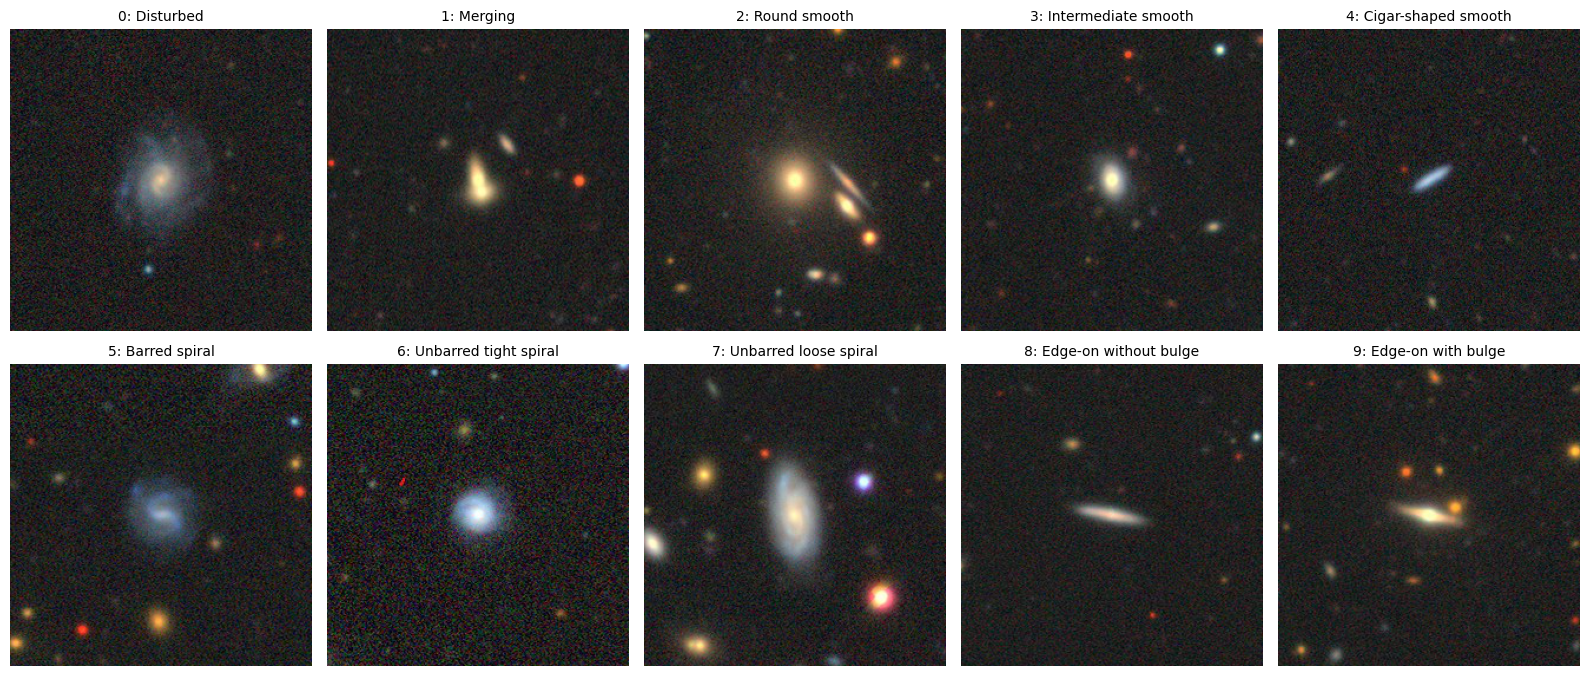

In [7]:



fig, axes = plt.subplots(2, 5, figsize=(16, 7))

for class_id, ax in enumerate(axes.flat):
    index = int(np.flatnonzero(labels == class_id)[0])

    image = galaxies[index]["rgb_image"].convert("RGB")

    ax.imshow(image)
    ax.set_title(
        f"{class_id}: {CLASS_NAMES[class_id]}",
        fontsize=10,
    )
    ax.axis("off")

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR_IMAGES / "class_examples.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

In [7]:
# split train, validation , test

In [8]:
all_indices = np.arange(len(galaxies))

train_indices, test_indices = train_test_split(all_indices,test_size=0.20,random_state=SEED,stratify=labels,)

assert set(train_indices).isdisjoint(set(test_indices))

np.savez(OUTPUT_DIR / "split_indices.npz",train_indices=train_indices,test_indices=test_indices)

print("Training images:", len(train_indices))
print("Test images:", len(test_indices))

print("\nClass distribution:")
print(f"{'Class':30s} {'Train':>8s} {'Test':>8s}")

for class_id, name in enumerate(CLASS_NAMES):
    n_train = np.sum(labels[train_indices] == class_id)
    n_test = np.sum(labels[test_indices] == class_id)

    print(f"{name:30s} {n_train:8d} {n_test:8d}")

Training images: 14188
Test images: 3548

Class distribution:
Class                             Train     Test
Disturbed                           865      216
Merging                            1482      371
Round smooth                       2116      529
Intermediate smooth                1622      405
Cigar-shaped smooth                 267       67
Barred spiral                      1634      409
Unbarred tight spiral              1463      366
Unbarred loose spiral              2102      526
Edge-on without bulge              1139      284
Edge-on with bulge                 1498      375


In [9]:
image_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=transforms.InterpolationMode.BICUBIC,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

class GalaxyDataset(Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        sample = self.dataset[index]

        image = sample["rgb_image"].convert("RGB")
        image = self.transform(image)

        label = int(sample["gz10_label"])

        return image, label

image_dataset = GalaxyDataset(
    galaxies,
    image_transform,
)

feature_loader = DataLoader(
image_dataset,
    batch_size=FEATURE_BATCH_SIZE,
    shuffle=False,       # Preserve alignment with the original row indices
    num_workers=0,       # Simple and reliable in Colab
    pin_memory=True,
)

images_batch, labels_batch = next(iter(feature_loader))

print("Image batch:", images_batch.shape)
print("Label batch:", labels_batch.shape)

Image batch: torch.Size([32, 3, 224, 224])
Label batch: torch.Size([32])


In [10]:
backbone = torch.hub.load(
    "facebookresearch/dinov2",
    MODEL_NAME,
    pretrained=True,
    trust_repo=True,
)

backbone = backbone.to(device)
backbone.eval()

# Freeze every backbone parameter.
backbone.requires_grad_(False)

print("Model:", MODEL_NAME)
print(
    "Trainable backbone parameters:",
    sum(p.numel() for p in backbone.parameters() if p.requires_grad),
)

with torch.inference_mode():
    example_features = backbone(images_batch[:2].to(device))

print("Example embedding shape:", example_features.shape)

assert example_features.shape == (2, EMBEDDING_DIM)

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 175MB/s]


Model: dinov2_vits14
Trainable backbone parameters: 0
Example embedding shape: torch.Size([2, 384])


In [11]:
FEATURE_CACHE = OUTPUT_DIR / f"{MODEL_NAME}_features.npz"

cache_metadata = {
    "dataset_id": DATASET_ID,
    "dataset_revision": DATASET_REVISION,
    "model": MODEL_NAME,
    "image_size": IMAGE_SIZE,
    "preprocessing": "whole_image_bicubic_resize_imagenet_normalization",
    "n_images": len(galaxies),
}

cache_metadata_json = json.dumps(cache_metadata, sort_keys=True)

use_cache = False

if FEATURE_CACHE.exists():
    with np.load(FEATURE_CACHE, allow_pickle=False) as cached:
        matching_metadata = (
            cached["metadata"].item() == cache_metadata_json
        )
        matching_labels = np.array_equal(cached["labels"], labels)

        if matching_metadata and matching_labels:
            features = cached["features"].copy()
            use_cache = True

if use_cache:
    print("Loaded cached embeddings:", features.shape)

else:
    feature_batches = []
    extracted_label_batches = []

    with torch.inference_mode():
        for images, batch_labels in tqdm(
            feature_loader,
            desc="Extracting DINOv2 embeddings",
        ):
            images = images.to(device, non_blocking=True)

            embeddings = backbone(images)

            feature_batches.append(
                embeddings.cpu().numpy()
            )
            extracted_label_batches.append(
                batch_labels.numpy()
            )

    features = np.concatenate(feature_batches).astype(np.float32)

    extracted_labels = np.concatenate(extracted_label_batches)

    assert np.array_equal(extracted_labels, labels)

    np.savez_compressed(
        FEATURE_CACHE,
        features=features,
        labels=labels,
        metadata=cache_metadata_json,
    )

    print("Saved embeddings:", features.shape)

assert features.shape == (len(galaxies), EMBEDDING_DIM)
assert np.isfinite(features).all()

# The backbone is no longer needed during classifier training.
del backbone
gc.collect()
torch.cuda.empty_cache()

print("Feature extraction complete.")

Extracting DINOv2 embeddings:   0%|          | 0/555 [00:00<?, ?it/s]

Saved embeddings: (17736, 384)
Feature extraction complete.


In [12]:
X_train = torch.from_numpy(features[train_indices])
y_train = torch.from_numpy(labels[train_indices])

X_test = torch.from_numpy(features[test_indices])
y_test = labels[test_indices]

training_dataset = TensorDataset(X_train, y_train)

training_loader = DataLoader(
    training_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
    num_workers=0,
    pin_memory=True,
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: torch.Size([14188, 384])
y_train: torch.Size([14188])
X_test: torch.Size([3548, 384])
y_test: (3548,)


In [13]:
class GalaxyMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, num_classes=10):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.network(x)

set_seed(SEED)

classifier = GalaxyMLP(
    input_dim=EMBEDDING_DIM,
    hidden_dim=256,
    num_classes=10,
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    classifier.parameters(),
    lr=LEARNING_RATE,
)

print(classifier)

GalaxyMLP(
  (network): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [14]:
history = {"train_loss": [],"train_accuracy": [],}

for epoch in range(EPOCHS):
    classifier.train()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for batch_features, batch_labels in training_loader:
        batch_features = batch_features.to(
            device,
            non_blocking=True,
        )
        batch_labels = batch_labels.to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad(set_to_none=True)

        logits = classifier(batch_features)
        loss = criterion(logits, batch_labels)

        loss.backward()
        optimizer.step()

        batch_size = batch_labels.size(0)

        total_loss += loss.item() * batch_size
        total_correct += (
            logits.argmax(dim=1) == batch_labels
        ).sum().item()
        total_examples += batch_size

    epoch_loss = total_loss / total_examples
    epoch_accuracy = total_correct / total_examples

    history["train_loss"].append(epoch_loss)
    history["train_accuracy"].append(epoch_accuracy)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train loss: {epoch_loss:.4f} | "
        f"Train accuracy: {epoch_accuracy:.4f}"
    )

torch.save(
    {
        "model_state_dict": classifier.state_dict(),
        "model_name": MODEL_NAME,
        "input_dim": EMBEDDING_DIM,
        "hidden_dim": 256,
        "num_classes": 10,
        "epochs": EPOCHS,
        "seed": SEED,
    },
    OUTPUT_DIR / f"{MODEL_NAME}_mlp.pt",
)

print("\nTraining finished. Saved the final epoch checkpoint.")

Epoch 01/30 | Train loss: 1.3651 | Train accuracy: 0.5082
Epoch 02/30 | Train loss: 1.1231 | Train accuracy: 0.5988
Epoch 03/30 | Train loss: 1.0949 | Train accuracy: 0.6060
Epoch 04/30 | Train loss: 1.0439 | Train accuracy: 0.6256
Epoch 05/30 | Train loss: 1.0225 | Train accuracy: 0.6287
Epoch 06/30 | Train loss: 0.9922 | Train accuracy: 0.6429
Epoch 07/30 | Train loss: 0.9488 | Train accuracy: 0.6582
Epoch 08/30 | Train loss: 0.9377 | Train accuracy: 0.6672
Epoch 09/30 | Train loss: 0.9207 | Train accuracy: 0.6711
Epoch 10/30 | Train loss: 0.9391 | Train accuracy: 0.6673
Epoch 11/30 | Train loss: 0.9260 | Train accuracy: 0.6688
Epoch 12/30 | Train loss: 0.8886 | Train accuracy: 0.6845
Epoch 13/30 | Train loss: 0.9042 | Train accuracy: 0.6796
Epoch 14/30 | Train loss: 0.9096 | Train accuracy: 0.6764
Epoch 15/30 | Train loss: 0.8827 | Train accuracy: 0.6853
Epoch 16/30 | Train loss: 0.8740 | Train accuracy: 0.6893
Epoch 17/30 | Train loss: 0.8868 | Train accuracy: 0.6845
Epoch 18/30 | 

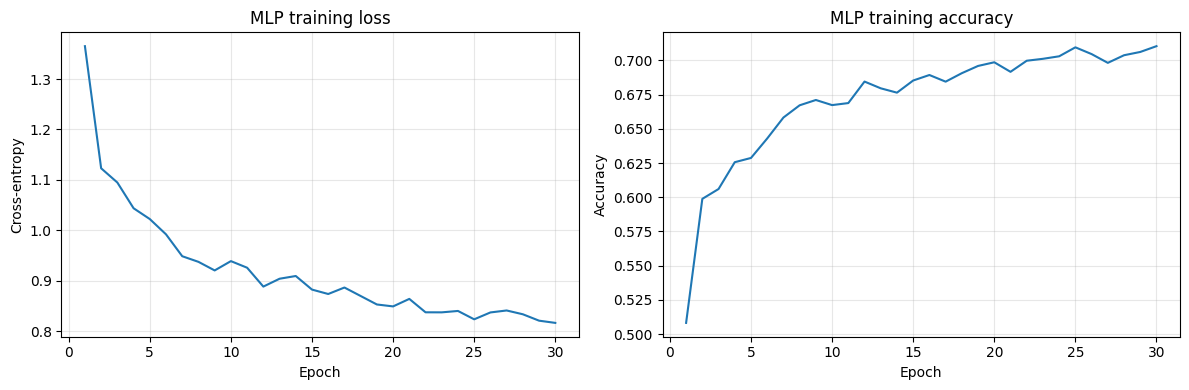

In [15]:
epochs_axis = np.arange(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_axis, history["train_loss"])
axes[0].set_title("MLP training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy")
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_axis, history["train_accuracy"])
axes[1].set_title("MLP training accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "training_curves.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

In [16]:
test_loader = DataLoader(
    TensorDataset(X_test),
    batch_size=256,
    shuffle=False,
)

classifier.eval()

prediction_batches = []

with torch.inference_mode():
    for (batch_features,) in test_loader:
        logits = classifier(batch_features.to(device))

        prediction_batches.append(
            logits.argmax(dim=1).cpu().numpy()
        )

y_pred = np.concatenate(prediction_batches)

test_accuracy = accuracy_score(y_test, y_pred)
test_macro_f1 = f1_score(
    y_test,
    y_pred,
    labels=np.arange(10),
    average="macro",
    zero_division=0,
)

print(f"Test accuracy: {test_accuracy:.4f} ({100 * test_accuracy:.2f}%)")
print(f"Test macro-F1: {test_macro_f1:.4f}")

report = classification_report(
    y_test,
    y_pred,
    labels=np.arange(10),
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
)

print("\n", report)

(OUTPUT_DIR / "classification_report.txt").write_text(report)

np.savez(
    OUTPUT_DIR / "test_predictions.npz",
    test_indices=test_indices,
    true_labels=y_test,
    predictions=y_pred,
)

Test accuracy: 0.6657 (66.57%)
Test macro-F1: 0.6395

                        precision    recall  f1-score   support

            Disturbed     0.3496    0.1991    0.2537       216
              Merging     0.7336    0.5418    0.6233       371
         Round smooth     0.7647    0.7618    0.7633       529
  Intermediate smooth     0.7387    0.7259    0.7323       405
  Cigar-shaped smooth     0.5588    0.5672    0.5630        67
        Barred spiral     0.7174    0.5648    0.6320       409
Unbarred tight spiral     0.5382    0.7514    0.6271       366
Unbarred loose spiral     0.5100    0.5798    0.5427       526
Edge-on without bulge     0.8587    0.8345    0.8464       284
   Edge-on with bulge     0.7428    0.8933    0.8111       375

             accuracy                         0.6657      3548
            macro avg     0.6512    0.6420    0.6395      3548
         weighted avg     0.6679    0.6657    0.6601      3548



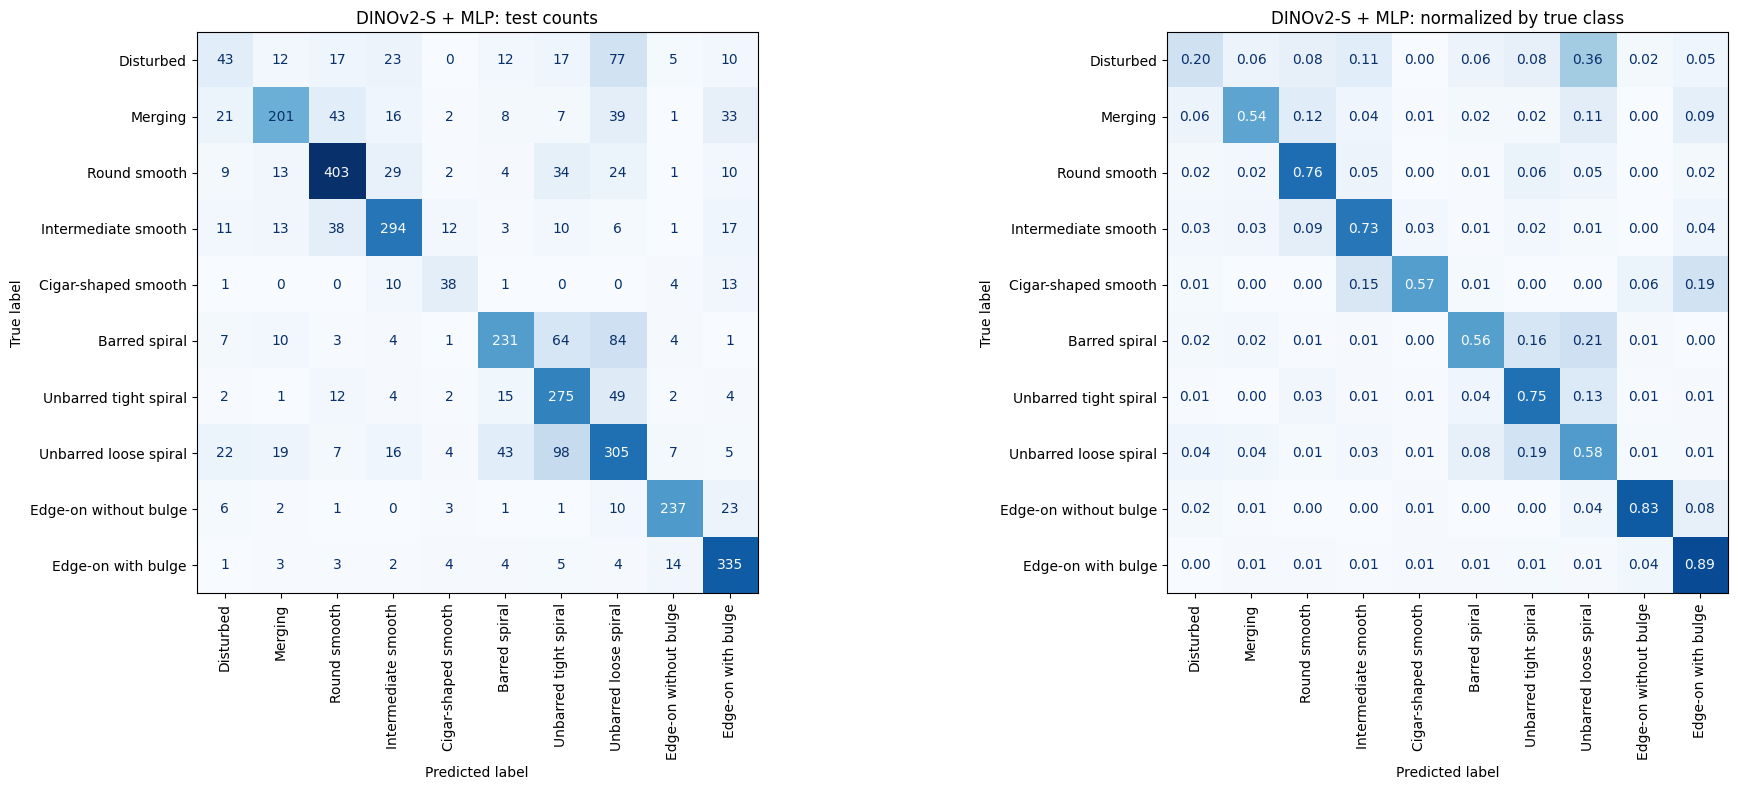

In [17]:
cm_counts = confusion_matrix(
    y_test,
    y_pred,
    labels=np.arange(10),
)

cm_normalized = confusion_matrix(
    y_test,
    y_pred,
    labels=np.arange(10),
    normalize="true",
)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

ConfusionMatrixDisplay(
    confusion_matrix=cm_counts,
    display_labels=CLASS_NAMES,
).plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False,
    xticks_rotation=90,
    values_format="d",
)

axes[0].set_title("DINOv2-S + MLP: test counts")

ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=CLASS_NAMES,
).plot(
    ax=axes[1],
    cmap="Blues",
    colorbar=False,
    xticks_rotation=90,
    values_format=".2f",
)

axes[1].images[0].set_clim(0, 1)
axes[1].set_title("DINOv2-S + MLP: normalized by true class")

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "confusion_matrices.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

In [18]:
paper_accuracy = 0.67

print("Model: DINOv2-S/14 + MLP")
print(f"Paper reference accuracy: {100 * paper_accuracy:.2f}%")
print(f"Our test accuracy:       {100 * test_accuracy:.2f}%")
print(
    "Difference: "
    f"{100 * (test_accuracy - paper_accuracy):+.2f} percentage points"
)

print(
    "\nThis is a method reproduction, not a guaranteed exact numerical "
    "replication. Dataset images, split seed and unspecified settings "
    "may differ."
)

results = {
    "dataset_id": DATASET_ID,
    "dataset_revision": DATASET_REVISION,
    "dataset_fingerprint": galaxies._fingerprint,
    "n_images": len(galaxies),
    "n_train": len(train_indices),
    "n_test": len(test_indices),
    "model": MODEL_NAME,
    "embedding_dim": EMBEDDING_DIM,
    "hidden_dim": 256,
    "image_size": IMAGE_SIZE,
    "optimizer": "Adam",
    "learning_rate": LEARNING_RATE,
    "learning_rate_source": "assumed; unspecified in report",
    "batch_size": TRAIN_BATCH_SIZE,
    "epochs": EPOCHS,
    "seed": SEED,
    "stratified_split": True,
    "feature_standardization": False,
    "test_accuracy": float(test_accuracy),
    "test_macro_f1": float(test_macro_f1),
    "paper_reference_accuracy": paper_accuracy,
    "torch_version": torch.__version__,
    "gpu": torch.cuda.get_device_name(0),
}

(OUTPUT_DIR / "results.json").write_text(
    json.dumps(results, indent=2)
)

(OUTPUT_DIR / "training_history.json").write_text(
    json.dumps(history, indent=2)
)

print("\nResults saved to:", OUTPUT_DIR)

Model: DINOv2-S/14 + MLP
Paper reference accuracy: 67.00%
Our test accuracy:       66.57%
Difference: -0.43 percentage points

This is a method reproduction, not a guaranteed exact numerical replication. Dataset images, split seed and unspecified settings may differ.

Results saved to: /content/astrodino_results


In [24]:
## Segmentatioin

In [19]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

from torchvision import transforms

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

OUTPUT_DIR_ATTENTION = Path("/content/astrodino_attention")
OUTPUT_DIR_ATTENTION.mkdir(parents=True, exist_ok=True)

# Section 5.1 uses the ORIGINAL DINO ViT-S/8.
dino_model = torch.hub.load(
    "facebookresearch/dino:main",
    "dino_vits8",
    pretrained=True,
    trust_repo=True,
)

dino_model = dino_model.to(device).eval()
dino_model.requires_grad_(False)

print("Device:", device)
print("Model: DINO ViT-S/8")

Downloading: "https://github.com/facebookresearch/dino/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dino/dino_deitsmall8_pretrain/dino_deitsmall8_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dino_deitsmall8_pretrain.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 351MB/s]


Device: cuda
Model: DINO ViT-S/8


In [20]:
INPUT_SIZE = 224
PATCH_SIZE = 8

attention_transform = transforms.Compose([
    transforms.Resize(
        (INPUT_SIZE, INPUT_SIZE),
        interpolation=transforms.InterpolationMode.BICUBIC,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

In [21]:
@torch.inference_mode()
def extract_attention_and_masks(image, cumulative_cutoff=0.60):
    """
    cumulative_cutoff=0.60:
        Sort patch attention from smallest to largest.
        Discard approximately the lowest 60% of attention mass.
        Keep the remaining highest-attention patches (~40% mass).

    This is NOT a threshold of 0.60 on individual attention values.
    """
    if not 0 < cumulative_cutoff < 1:
        raise ValueError("cumulative_cutoff must be between 0 and 1.")

    image = image.convert("RGB")

    display_image = image.resize(
        (INPUT_SIZE, INPUT_SIZE),
        resample=__import__("PIL").Image.Resampling.BICUBIC,
    )

    x = attention_transform(image).unsqueeze(0).to(device)

    # Shape: [batch, heads, tokens, tokens]
    attention = dino_model.get_last_selfattention(x)

    # Token 0 is CLS. Tokens 1 onward are image patches.
    # Shape: [heads, patches]
    cls_attention = attention[0, :, 0, 1:]

    n_heads, n_patches = cls_attention.shape
    grid_height = x.shape[-2] // PATCH_SIZE
    grid_width = x.shape[-1] // PATCH_SIZE

    assert n_patches == grid_height * grid_width

    # Continuous attention maps at patch resolution.
    patch_maps = cls_attention.reshape(
        n_heads, grid_height, grid_width
    )

    # Sort each head's attention from lowest to highest.
    sorted_attention, sorted_indices = torch.sort(
        cls_attention,
        dim=1,
    )

    # Normalize over image patches, excluding CLS self-attention.
    sorted_attention = sorted_attention / (
        sorted_attention.sum(dim=1, keepdim=True).clamp_min(1e-12)
    )

    cumulative_mass = torch.cumsum(sorted_attention, dim=1)

    # Matches the original DINO visualization's cumulative threshold.
    sorted_masks = cumulative_mass > cumulative_cutoff

    # Restore masks to the original spatial patch order.
    patch_masks = torch.zeros_like(
        cls_attention,
        dtype=torch.bool,
    )

    patch_masks.scatter_(
        dim=1,
        index=sorted_indices,
        src=sorted_masks,
    )

    # Diagnostic: actual retained attention mass, slightly above 40%
    # because patches are discrete.
    normalized_attention = cls_attention / (
        cls_attention.sum(dim=1, keepdim=True).clamp_min(1e-12)
    )

    retained_mass = (
        normalized_attention * patch_masks
    ).sum(dim=1)

    patch_masks = patch_masks.reshape(
        n_heads, grid_height, grid_width
    )

    # Upsample maps and masks using nearest-neighbor interpolation.
    full_maps = F.interpolate(
        patch_maps.unsqueeze(0),
        size=(INPUT_SIZE, INPUT_SIZE),
        mode="nearest",
    )[0]

    full_masks = F.interpolate(
        patch_masks.float().unsqueeze(0),
        size=(INPUT_SIZE, INPUT_SIZE),
        mode="nearest",
    )[0].bool()

    return {
        "image": np.asarray(display_image),
        "attention_maps": full_maps.cpu().numpy(),
        "masks": full_masks.cpu().numpy(),
        "patch_attention": cls_attention.cpu().numpy(),
        "retained_mass": retained_mass.cpu().numpy(),
        "grid_shape": (grid_height, grid_width),
    }

In [28]:
def plot_attention_results(result, title="Galaxy", save_path=None):
    image = result["image"]
    maps = result["attention_maps"]
    masks = result["masks"]
    retained_mass = result["retained_mass"]

    n_heads = len(maps)

    fig, axes = plt.subplots(
        n_heads,
        4,
        figsize=(13, 3 * n_heads),
        squeeze=False,
    )

    for head in range(n_heads):
        axes[head, 0].imshow(image)
        axes[head, 0].set_title("Input image")

        # Per-head display scaling for visualization only.
        axes[head, 1].imshow(maps[head], cmap="inferno")
        axes[head, 1].set_title(f"Head {head + 1}: attention")

        axes[head, 2].imshow(
            masks[head],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[head, 2].set_title(
            f"Mask: {100 * retained_mass[head]:.1f}% attention mass"
        )

        axes[head, 3].imshow(image)

        # Transparent outside mask; red inside mask.
        overlay = np.zeros(
            (INPUT_SIZE, INPUT_SIZE, 4),
            dtype=np.float32,
        )
        overlay[..., 0] = 1.0
        overlay[..., 3] = masks[head].astype(np.float32) * 0.45

        axes[head, 3].imshow(overlay)
        axes[head, 3].set_title("Mask overlay")

        for ax in axes[head]:
            ax.axis("off")

    fig.suptitle(title, fontsize=15)
    fig.tight_layout(rect=[0, 0, 1, 0.98])

    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()
    plt.close(fig)

Patch grid: (28, 28)
Attention maps: (6, 224, 224)
Binary masks: (6, 224, 224)
Retained mass per head: [0.40063912 0.40149134 0.40430224 0.4035413  0.40492088 0.40526515]


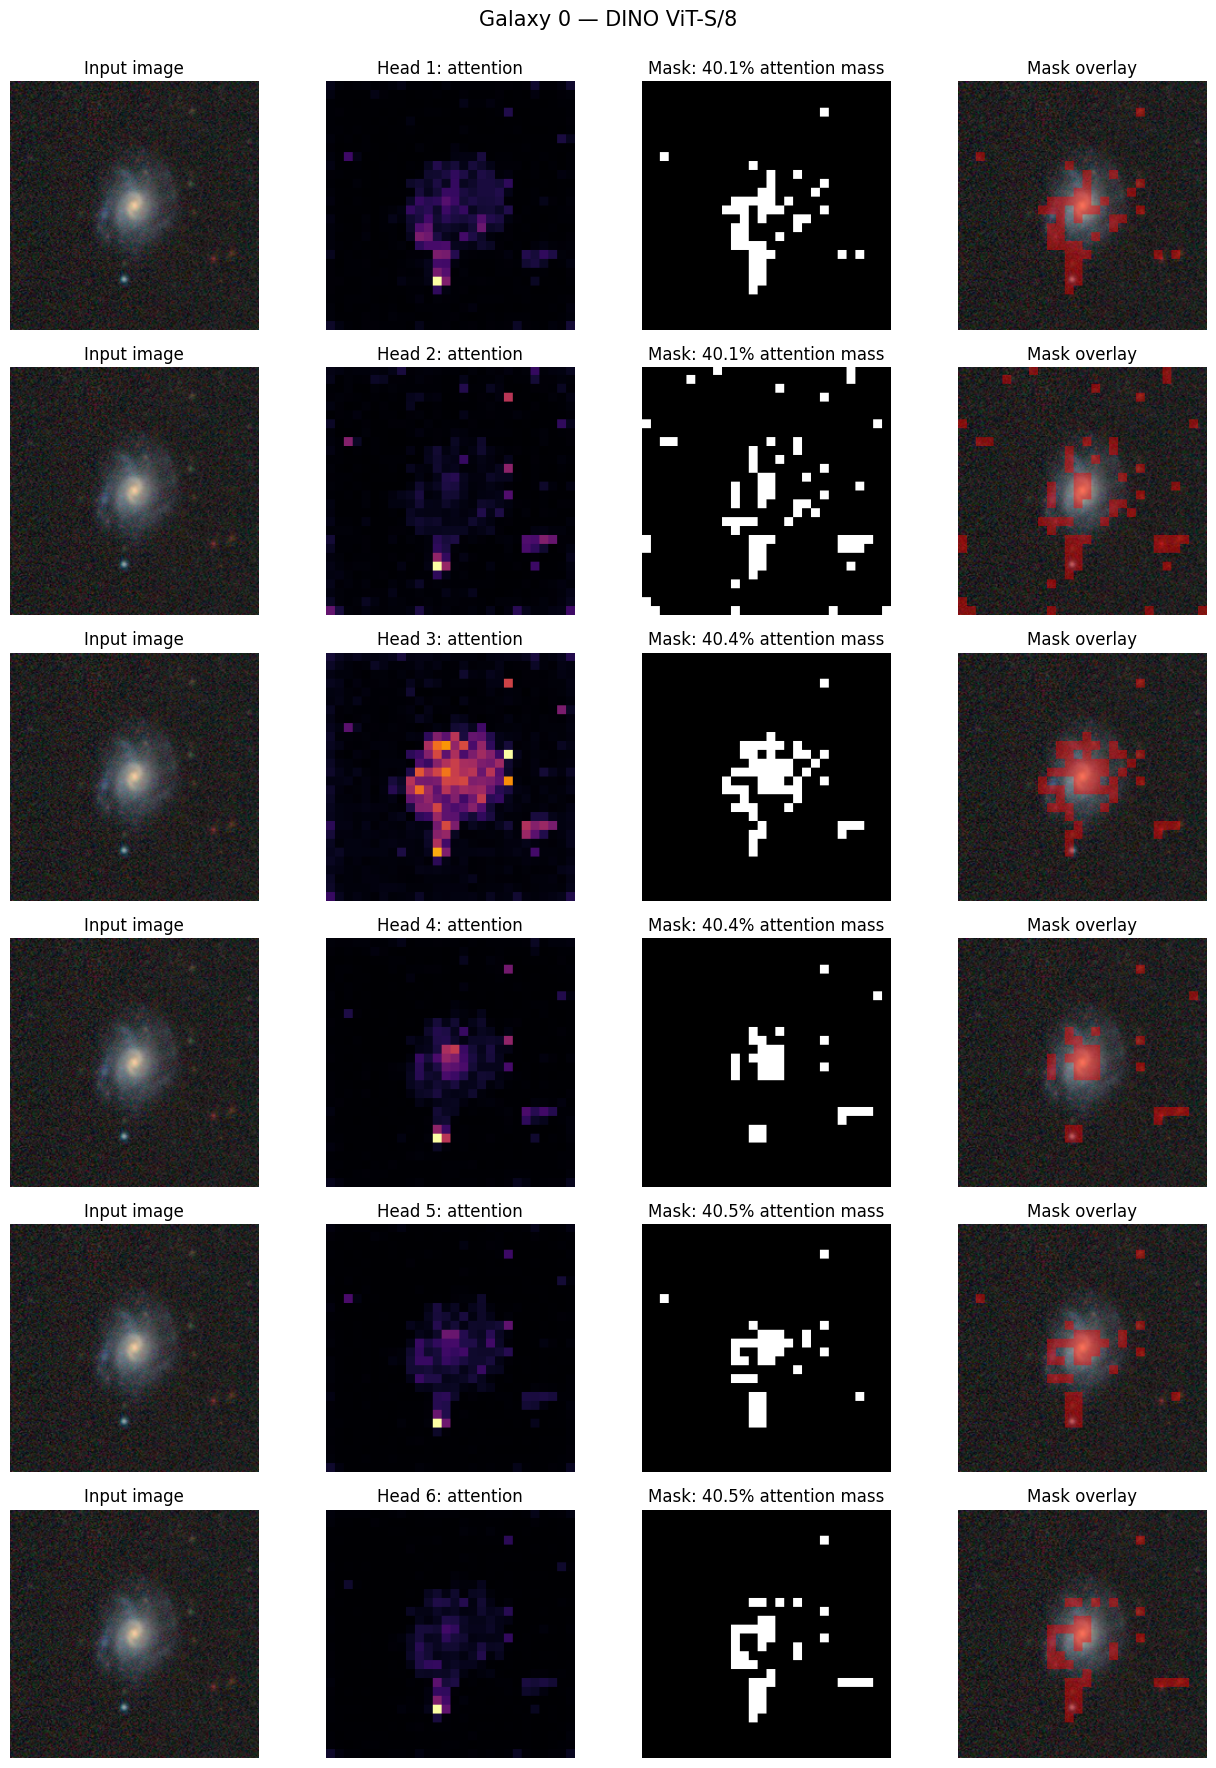

In [29]:
IMAGE_INDEX = 0  # Change this to inspect another galaxy.

image = galaxies[IMAGE_INDEX]["rgb_image"].convert("RGB")

result = extract_attention_and_masks(
    image,
    cumulative_cutoff=0.60,
)

print("Patch grid:", result["grid_shape"])
print("Attention maps:", result["attention_maps"].shape)
print("Binary masks:", result["masks"].shape)
print("Retained mass per head:", result["retained_mass"])

plot_attention_results(
    result,
    title=f"Galaxy {IMAGE_INDEX} — DINO ViT-S/8",
    save_path=OUTPUT_DIR_ATTENTION / f"galaxy_{IMAGE_INDEX}.png",
)

np.savez_compressed(
    OUTPUT_DIR_ATTENTION / f"galaxy_{IMAGE_INDEX}_attention.npz",
    image=result["image"],
    attention_maps=result["attention_maps"],
    masks=result["masks"],
    patch_attention=result["patch_attention"],
    retained_mass=result["retained_mass"],
)

In [42]:
## fine-tune

In [22]:
import copy
import gc
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import (
    Dataset,
    DataLoader,
    TensorDataset,
)
from torchvision import transforms
from tqdm.auto import tqdm

SEED = 42
EPOCHS = 30
BATCH_SIZE = 64

HEAD_LR = 1e-3
BACKBONE_LR = 1e-5  # Smaller updates to pretrained weights

ADAPT_DIR = Path("/content/astrodino_adaptation")
ADAPT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda", "Enable a GPU runtime."

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Preserve your original split.
original_train_indices = np.asarray(train_indices).copy()
fixed_test_indices = np.asarray(test_indices).copy()

adapt_train_indices, val_indices = train_test_split(
    original_train_indices,
    test_size=0.20,
    random_state=SEED,
    stratify=labels[original_train_indices],
)

assert set(adapt_train_indices).isdisjoint(val_indices)
assert set(adapt_train_indices).isdisjoint(fixed_test_indices)
assert set(val_indices).isdisjoint(fixed_test_indices)

np.savez(
    ADAPT_DIR / "splits.npz",
    train_indices=adapt_train_indices,
    val_indices=val_indices,
    test_indices=fixed_test_indices,
)

print("Train:", len(adapt_train_indices))
print("Validation:", len(val_indices))
print("Test:", len(fixed_test_indices))

Train: 11350
Validation: 2838
Test: 3548


In [23]:
adapt_transform = transforms.Compose([
    transforms.Resize(
        (224, 224),
        interpolation=transforms.InterpolationMode.BICUBIC,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

class IndexedGalaxyDataset(Dataset):
    def __init__(self, galaxies, indices, transform):
        self.galaxies = galaxies
        self.indices = np.asarray(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, position):
        index = int(self.indices[position])
        sample = self.galaxies[index]

        image = sample["rgb_image"].convert("RGB")
        image = self.transform(image)
        label = int(sample["gz10_label"])

        return image, label


def make_loader(dataset, shuffle=False):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=True,
        generator=torch.Generator().manual_seed(SEED),
    )


image_train_dataset = IndexedGalaxyDataset(
    galaxies, adapt_train_indices, adapt_transform
)

image_val_dataset = IndexedGalaxyDataset(
    galaxies, val_indices, adapt_transform
)

image_test_dataset = IndexedGalaxyDataset(
    galaxies, fixed_test_indices, adapt_transform
)

# Cached features are used only for the frozen baseline.
features = np.asarray(features, dtype=np.float32)
assert features.shape == (len(labels), 384)

def embedding_dataset(indices):
    return TensorDataset(
        torch.from_numpy(features[indices]),
        torch.from_numpy(labels[indices].astype(np.int64)),
    )

baseline_train_dataset = embedding_dataset(adapt_train_indices)
baseline_val_dataset = embedding_dataset(val_indices)
baseline_test_dataset = embedding_dataset(fixed_test_indices)

In [24]:
class MorphologyMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(384, 256),
            nn.ReLU(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.network(x)


class LastBlockDINOv2(nn.Module):
    def __init__(self, head_initial_state):
        super().__init__()

        self.backbone = torch.hub.load(
            "facebookresearch/dinov2",
            "dinov2_vits14",
            pretrained=True,
            trust_repo=True,
        )

        # First freeze the entire backbone.
        self.backbone.requires_grad_(False)

        # Then unfreeze exactly its last transformer block.
        self.backbone.blocks[-1].requires_grad_(True)

        self.head = MorphologyMLP()
        self.head.load_state_dict(head_initial_state)

    def train(self, mode=True):
        super().train(mode)

        # Frozen backbone components remain in evaluation mode.
        self.backbone.eval()

        # Only the last block and classifier enter training mode.
        self.backbone.blocks[-1].train(mode)
        self.head.train(mode)

        return self

    def forward(self, images):
        # Do NOT wrap this in no_grad(): the last block needs gradients.
        embeddings = self.backbone(images)
        return self.head(embeddings)


# Both experiments start from identical random MLP weights.
seed_everything(SEED)
head_initial_state = copy.deepcopy(
    MorphologyMLP().state_dict()
)

In [25]:
@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()

    total_loss = 0.0
    targets = []
    predictions = []

    for inputs, batch_labels in loader:
        inputs = inputs.to(device, non_blocking=True)
        batch_labels = batch_labels.to(device, non_blocking=True)

        logits = model(inputs)
        loss = nn.functional.cross_entropy(logits, batch_labels)

        total_loss += loss.item() * len(batch_labels)
        targets.append(batch_labels.cpu().numpy())
        predictions.append(logits.argmax(1).cpu().numpy())

    targets = np.concatenate(targets)
    predictions = np.concatenate(predictions)

    return {
        "loss": total_loss / len(targets),
        "accuracy": accuracy_score(targets, predictions),
        "macro_f1": f1_score(
            targets,
            predictions,
            labels=np.arange(10),
            average="macro",
            zero_division=0,
        ),
        "targets": targets,
        "predictions": predictions,
    }


def fit_model(model, optimizer, train_loader, val_loader, name):
    history = []
    best_f1 = -1.0
    best_epoch = None
    best_state = None

    # Save only trainable parameters.
    trainable_names = {
        name for name, parameter in model.named_parameters()
        if parameter.requires_grad
    }

    for epoch in range(1, EPOCHS + 1):
        model.train()

        total_loss = 0.0
        total_correct = 0
        total_examples = 0

        for inputs, batch_labels in tqdm(
            train_loader,
            desc=f"{name}: epoch {epoch}/{EPOCHS}",
            leave=False,
        ):
            inputs = inputs.to(device, non_blocking=True)
            batch_labels = batch_labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            logits = model(inputs)
            loss = nn.functional.cross_entropy(logits, batch_labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(batch_labels)
            total_correct += (
                logits.argmax(1) == batch_labels
            ).sum().item()
            total_examples += len(batch_labels)

        validation = evaluate_model(model, val_loader)

        record = {
            "epoch": epoch,
            "train_loss": total_loss / total_examples,
            "train_accuracy": total_correct / total_examples,
            "val_loss": validation["loss"],
            "val_accuracy": validation["accuracy"],
            "val_macro_f1": validation["macro_f1"],
        }
        history.append(record)

        if validation["macro_f1"] > best_f1:
            best_f1 = validation["macro_f1"]
            best_epoch = epoch

            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
                if key in trainable_names
            }

            torch.save(
                {
                    "trainable_state_dict": best_state,
                    "epoch": best_epoch,
                    "val_macro_f1": best_f1,
                    "backbone": "dinov2_vits14",
                },
                ADAPT_DIR / f"{name}_best.pt",
            )

        print(
            f"{name} | epoch {epoch:02d} | "
            f"train loss {record['train_loss']:.4f} | "
            f"val accuracy {record['val_accuracy']:.4f} | "
            f"val F1 {record['val_macro_f1']:.4f}"
        )

        # Preserve progress if the Colab session stops.
        (ADAPT_DIR / f"{name}_history.json").write_text(
            json.dumps(history, indent=2)
        )

    # Restore the validation-selected checkpoint.
    model.load_state_dict(best_state, strict=False)

    print(f"\n{name}: selected epoch {best_epoch}, val F1 {best_f1:.4f}")

    return history, best_epoch

In [47]:
seed_everything(SEED)

frozen_baseline = MorphologyMLP().to(device)
frozen_baseline.load_state_dict(head_initial_state)

baseline_optimizer = torch.optim.Adam(
    frozen_baseline.parameters(),
    lr=HEAD_LR,
)

baseline_history, baseline_best_epoch = fit_model(
    frozen_baseline,
    baseline_optimizer,
    make_loader(baseline_train_dataset, shuffle=True),
    make_loader(baseline_val_dataset),
    name="frozen",
)

# Keep the trained baseline on CPU until final evaluation.
frozen_baseline.cpu()

del baseline_optimizer
gc.collect()
torch.cuda.empty_cache()

frozen: epoch 1/30:   0%|          | 0/178 [00:00<?, ?it/s]

frozen | epoch 01 | train loss 1.4210 | val accuracy 0.5828 | val F1 0.4965


frozen: epoch 2/30:   0%|          | 0/178 [00:00<?, ?it/s]

frozen | epoch 02 | train loss 1.1425 | val accuracy 0.5832 | val F1 0.5421


frozen: epoch 3/30:   0%|          | 0/178 [00:00<?, ?it/s]

...

frozen | epoch 28 | train loss 0.7280 | val accuracy 0.6709 | val F1 0.6365


frozen: epoch 29/30:   0%|          | 0/178 [00:00<?, ?it/s]

frozen | epoch 29 | train loss 0.7277 | val accuracy 0.6670 | val F1 0.6402


frozen: epoch 30/30:   0%|          | 0/178 [00:00<?, ?it/s]

frozen | epoch 30 | train loss 0.7185 | val accuracy 0.6628 | val F1 0.6093

frozen: selected epoch 16, val F1 0.6468


In [48]:
seed_everything(SEED)

adapted_model = LastBlockDINOv2(
    head_initial_state
).to(device)

last_block_parameters = list(
    adapted_model.backbone.blocks[-1].parameters()
)

adapt_optimizer = torch.optim.Adam([
    {
        "params": last_block_parameters,
        "lr": BACKBONE_LR,
    },
    {
        "params": adapted_model.head.parameters(),
        "lr": HEAD_LR,
    },
])

print("Trainable modules:")
for name, parameter in adapted_model.named_parameters():
    if parameter.requires_grad:
        print(name)

# Verify no earlier backbone blocks are trainable.
assert all(
    not parameter.requires_grad
    for block in adapted_model.backbone.blocks[:-1]
    for parameter in block.parameters()
)

adapt_history, adapt_best_epoch = fit_model(
    adapted_model,
    adapt_optimizer,
    make_loader(image_train_dataset, shuffle=True),
    make_loader(image_val_dataset),
    name="last_block",
)

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Trainable modules:
backbone.blocks.11.norm1.weight
backbone.blocks.11.norm1.bias
backbone.blocks.11.attn.qkv.weight
backbone.blocks.11.attn.qkv.bias
backbone.blocks.11.attn.proj.weight
backbone.blocks.11.attn.proj.bias
backbone.blocks.11.ls1.gamma
backbone.blocks.11.norm2.weight
backbone.blocks.11.norm2.bias
backbone.blocks.11.mlp.fc1.weight
backbone.blocks.11.mlp.fc1.bias
backbone.blocks.11.mlp.fc2.weight
backbone.blocks.11.mlp.fc2.bias
backbone.blocks.11.ls2.gamma
head.network.0.weight
head.network.0.bias
head.network.2.weight
head.network.2.bias


last_block: epoch 1/30:   0%|          | 0/178 [00:00<?, ?it/s]

last_block | epoch 01 | train loss 1.2575 | val accuracy 0.6734 | val F1 0.6230


last_block: epoch 2/30:   0%|          | 0/178 [00:00<?, ?it/s]

...

last_block | epoch 28 | train loss 0.0820 | val accuracy 0.7456 | val F1 0.7090


last_block: epoch 29/30:   0%|          | 0/178 [00:00<?, ?it/s]

last_block | epoch 29 | train loss 0.0738 | val accuracy 0.7555 | val F1 0.7175


last_block: epoch 30/30:   0%|          | 0/178 [00:00<?, ?it/s]

last_block | epoch 30 | train loss 0.0458 | val accuracy 0.7565 | val F1 0.7323

last_block: selected epoch 6, val F1 0.7433


In [49]:
adapt_test = evaluate_model(
    adapted_model,
    make_loader(image_test_dataset),
)

adapted_model.cpu()
del adapt_optimizer
gc.collect()
torch.cuda.empty_cache()

frozen_baseline.to(device)

frozen_test = evaluate_model(
    frozen_baseline,
    make_loader(baseline_test_dataset),
)

assert np.array_equal(
    frozen_test["targets"],
    adapt_test["targets"],
)

print(f"{'Method':25s} {'Accuracy':>10s} {'Macro-F1':>10s}")
print(
    f"{'Frozen DINOv2 + MLP':25s} "
    f"{frozen_test['accuracy']:10.4f} "
    f"{frozen_test['macro_f1']:10.4f}"
)
print(
    f"{'Last block + MLP':25s} "
    f"{adapt_test['accuracy']:10.4f} "
    f"{adapt_test['macro_f1']:10.4f}"
)

accuracy_change = (
    adapt_test["accuracy"] - frozen_test["accuracy"]
) * 100

print(f"\nAccuracy change: {accuracy_change:+.2f} percentage points")

summary = {
    "seed": SEED,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "head_lr": HEAD_LR,
    "backbone_lr": BACKBONE_LR,
    "frozen": {
        "accuracy": float(frozen_test["accuracy"]),
        "macro_f1": float(frozen_test["macro_f1"]),
        "selected_epoch": baseline_best_epoch,
    },
    "last_block": {
        "accuracy": float(adapt_test["accuracy"]),
        "macro_f1": float(adapt_test["macro_f1"]),
        "selected_epoch": adapt_best_epoch,
    },
}

(ADAPT_DIR / "comparison.json").write_text(
    json.dumps(summary, indent=2)
)

np.savez(
    ADAPT_DIR / "test_predictions.npz",
    image_indices=fixed_test_indices,
    true_labels=adapt_test["targets"],
    frozen_predictions=frozen_test["predictions"],
    adapted_predictions=adapt_test["predictions"],
)

Method                      Accuracy   Macro-F1
Frozen DINOv2 + MLP           0.6694     0.6403
Last block + MLP              0.7632     0.7444

Accuracy change: +9.39 percentage points


In [26]:
### Lora Adaptation

In [27]:
import math
import copy
import json

import torch
import torch.nn as nn


class LoRAQKV(nn.Module):
    """
    Frozen original QKV projection.
    Trainable low-rank updates for Q and V.
    K remains unchanged.
    """

    def __init__(self, base_qkv, rank=8, alpha=16):
        super().__init__()

        if rank < 1:
            raise ValueError("rank must be positive.")

        self.base = base_qkv
        self.base.requires_grad_(False)

        self.dim = base_qkv.in_features

        assert base_qkv.out_features == 3 * self.dim

        self.rank = rank
        self.alpha = alpha
        self.scaling = alpha / rank

        self.q_A = nn.Linear(self.dim, rank, bias=False)
        self.q_B = nn.Linear(rank, self.dim, bias=False)

        self.v_A = nn.Linear(self.dim, rank, bias=False)
        self.v_B = nn.Linear(rank, self.dim, bias=False)

        # Nonzero A and zero B:
        # initially the LoRA update is exactly zero.
        nn.init.kaiming_uniform_(self.q_A.weight, a=math.sqrt(5))
        nn.init.kaiming_uniform_(self.v_A.weight, a=math.sqrt(5))

        nn.init.zeros_(self.q_B.weight)
        nn.init.zeros_(self.v_B.weight)

    def forward(self, x):
        original_qkv = self.base(x)

        delta_q = self.q_B(self.q_A(x)) * self.scaling
        delta_v = self.v_B(self.v_A(x)) * self.scaling

        delta_qkv = torch.cat(
            [
                delta_q,
                torch.zeros_like(delta_q),  # No update to K
                delta_v,
            ],
            dim=-1,
        )

        return original_qkv + delta_qkv

In [ ]:
backbone

In [28]:
class LoRADINOv2(nn.Module):
    def __init__(self, head_initial_state, rank=8, alpha=16):
        super().__init__()

        self.backbone = torch.hub.load(
            "facebookresearch/dinov2",
            "dinov2_vits14",
            pretrained=True,
            trust_repo=True,
        )

        # Freeze all original backbone parameters.
        self.backbone.requires_grad_(False)

        last_attention = self.backbone.blocks[-1].attn

        # Newly created LoRA matrices are trainable.
        last_attention.qkv = LoRAQKV(
            base_qkv=last_attention.qkv,
            rank=rank,
            alpha=alpha,
        )

        self.head = MorphologyMLP()
        self.head.load_state_dict(head_initial_state)

    def train(self, mode=True):
        super().train(mode)

        # Match the previous last-block experiment's mode settings.
        self.backbone.eval()
        self.backbone.blocks[-1].train(mode)
        self.head.train(mode)

        return self

    def forward(self, images):
        # Gradients are needed for the LoRA matrices.
        embeddings = self.backbone(images)
        return self.head(embeddings)

In [29]:
LORA_RANK = 8
LORA_ALPHA = 16
LORA_LR = 1e-4
HEAD_LR = 1e-3

seed_everything(SEED)

lora_model = LoRADINOv2(
    head_initial_state=head_initial_state,
    rank=LORA_RANK,
    alpha=LORA_ALPHA,
).to(device)

adapter = lora_model.backbone.blocks[-1].attn.qkv

# Verify that LoRA initially preserves the original projection.
with torch.no_grad():
    example_tokens = torch.randn(
        2, 5, 384,
        device=device,
    )

    torch.testing.assert_close(
        adapter(example_tokens),
        adapter.base(example_tokens),
    )

trainable_backbone_names = [
    name
    for name, parameter in lora_model.backbone.named_parameters()
    if parameter.requires_grad
]

expected_names = {
    f"blocks.{len(lora_model.backbone.blocks) - 1}.attn.qkv.{part}.weight"
    for part in ["q_A", "q_B", "v_A", "v_B"]
}

assert set(trainable_backbone_names) == expected_names

lora_parameters = [
    parameter
    for parameter in lora_model.backbone.parameters()
    if parameter.requires_grad
]

n_lora = sum(p.numel() for p in lora_parameters)
n_head = sum(p.numel() for p in lora_model.head.parameters())

print("Trainable backbone parameters:", n_lora)
print("Trainable MLP parameters:", n_head)
print("Total trainable parameters:", n_lora + n_head)

for name in trainable_backbone_names:
    print(name)

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Trainable backbone parameters: 12288
Trainable MLP parameters: 101130
Total trainable parameters: 113418
blocks.11.attn.qkv.q_A.weight
blocks.11.attn.qkv.q_B.weight
blocks.11.attn.qkv.v_A.weight
blocks.11.attn.qkv.v_B.weight


In [31]:
total = sum(p.numel() for p in lora_model.parameters())
trainable = sum(
    p.numel() for p in lora_model.parameters()
    if p.requires_grad
)

print(f"Total parameters:     {total:,}")
print(f"Trainable parameters: {trainable:,}")
print(f"Frozen parameters:    {total - trainable:,}")
print(f"Trainable percentage: {100 * trainable / total:.3f}%")

Total parameters:     22,169,994
Trainable parameters: 113,418
Frozen parameters:    22,056,576
Trainable percentage: 0.512%


In [32]:
lora_optimizer = torch.optim.Adam([
    {
        "params": lora_parameters,
        "lr": LORA_LR,
    },
    {
        "params": lora_model.head.parameters(),
        "lr": HEAD_LR,
    },
])

lora_config = {
    "backbone": "dinov2_vits14",
    "adapted_blocks": [len(lora_model.backbone.blocks) - 1],
    "target_projections": ["query", "value"],
    "rank": LORA_RANK,
    "alpha": LORA_ALPHA,
    "lora_lr": LORA_LR,
    "head_lr": HEAD_LR,
    "seed": SEED,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
}

(ADAPT_DIR / "lora_config.json").write_text(
    json.dumps(lora_config, indent=2)
)

lora_history, lora_best_epoch = fit_model(
    lora_model,
    lora_optimizer,
    make_loader(image_train_dataset, shuffle=True),
    make_loader(image_val_dataset),
    name="lora_last_block",
)

lora_last_block: epoch 1/30:   0%|          | 0/178 [00:00<?, ?it/s]

lora_last_block | epoch 01 | train loss 0.8828 | val accuracy 0.7266 | val F1 0.6807


lora_last_block: epoch 2/30:   0%|          | 0/178 [00:00<?, ?it/s]

lora_last_block | epoch 02 | train loss 0.7496 | val accuracy 0.7435 | val F1 0.7030


lora_last_block: epoch 3/30:   0%|          | 0/178 [00:00<?, ?it/s]

...

lora_last_block | epoch 28 | train loss 0.0789 | val accuracy 0.7622 | val F1 0.7284


lora_last_block: epoch 29/30:   0%|          | 0/178 [00:00<?, ?it/s]

lora_last_block | epoch 29 | train loss 0.0664 | val accuracy 0.7597 | val F1 0.7274


lora_last_block: epoch 30/30:   0%|          | 0/178 [00:00<?, ?it/s]

lora_last_block | epoch 30 | train loss 0.0669 | val accuracy 0.7622 | val F1 0.7342

lora_last_block: selected epoch 11, val F1 0.7504


In [35]:
lora_test = evaluate_model(
    lora_model,
    make_loader(image_test_dataset),
)

print(f"LoRA test accuracy: {lora_test['accuracy']:.4f}")
print(f"LoRA test macro-F1: {lora_test['macro_f1']:.4f}")

print(
    classification_report(
        lora_test["targets"],
        lora_test["predictions"],
        labels=np.arange(10),
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
)


print(f"\n{'Method':28s} {'Accuracy':>10s} {'Macro-F1':>10s}")

for title, result in [
    ("LoRA last block + MLP", lora_test),
]:
    print(
        f"{title:28s} "
        f"{result['accuracy']:10.4f} "
        f"{result['macro_f1']:10.4f}"
    )

LoRA test accuracy: 0.7807
LoRA test macro-F1: 0.7589
                       precision    recall  f1-score   support

            Disturbed     0.5600    0.3241    0.4106       216
              Merging     0.7658    0.7844    0.7750       371
         Round smooth     0.8399    0.9319    0.8835       529
  Intermediate smooth     0.8432    0.8765    0.8596       405
  Cigar-shaped smooth     0.7797    0.6866    0.7302        67
        Barred spiral     0.7662    0.8093    0.7872       409
Unbarred tight spiral     0.7339    0.6858    0.7090       366
Unbarred loose spiral     0.6273    0.6464    0.6367       526
Edge-on without bulge     0.8916    0.8979    0.8947       284
   Edge-on with bulge     0.9037    0.9013    0.9025       375

             accuracy                         0.7807      3548
            macro avg     0.7711    0.7544    0.7589      3548
         weighted avg     0.7743    0.7807    0.7750      3548


Method                         Accuracy   Macro-F1
LoRA last

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, normalize, title in [
    (axes[0], None, "LoRA + MLP — Counts"),
    (axes[1], "true", "LoRA + MLP — Normalized"),
]:
    cm = confusion_matrix(
        lora_test["targets"],
        lora_test["predictions"],
        labels=np.arange(len(CLASS_NAMES)),
        normalize=normalize,
    )

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASS_NAMES,
    ).plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        xticks_rotation=90,
        values_format="d" if normalize is None else ".2f",
    )

    ax.set_title(title)

    if normalize == "true":
        ax.images[0].set_clim(0, 1)

plt.tight_layout()
plt.show()